## Baselines

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_dataset

In [ ]:
def sample_bimodal_beta(n=5000, p=0.5, a=2, b=90):
    """
    Generate samples from a bimodal distribution on [0,1] using a mixture of two Beta distributions.

    With probability p:
        sample from Beta(a, b) → concentrated near 0
    Otherwise:
        sample from Beta(b, a) → concentrated near 1

    This creates a bimodal shape with peaks near 0 and 1.
    """
    xs = []
    for _ in range(n):
        if random.random() < p:
            xs.append(random.betavariate(a, b))
        else:
            xs.append(random.betavariate(b, a))
    return xs

In [ ]:
def generate_vectors(num_classes, no_of_examples):
    """
    Generate unique normalized proportion vectors.

    - Each vector sums to 1
    - Avoids duplicates
    - Avoids already existing vectors from dataset
    """

    seen = set()

    vectors = []

    while len(vectors) < no_of_examples:
        
        # Sample raw values from bimodal beta
        v = sample_bimodal_beta(n=num_classes, p=0.5, a=1, b=14)

        # Normalize to sum to 1
        s = sum(v)
        v = tuple(round(x / s, 3) for x in v)

        # Fix rounding drift (important)
        diff = 1.0 - sum(v)
        v = list(v)
        v[0] = round(v[0] + diff, 3)
        v = tuple(v)

        # Validate
        if v in seen or min(v) < 0.01 or sum(v)!=1:
            continue

        seen.add(v)
        vectors.append(v)

    return vectors

### Baseline 1  (centroid guess)

##### have 1/no_of_classes as the prediction and sample from the distribution that we usually use and compute the MAE

In [ ]:
num_classes = 3
num_examples = 800

In [ ]:
def distance_of_proportions(X, no_of_classes, ddof=0):
    """
    X: array shape (N,no_of_classes) with values in [0,1]
    
    returns:
    P: normalized proportions, shape (N,no_of_classes)
    """
    X = np.asarray(X, dtype=float)
    l1 = np.mean(np.abs(X - float(1/no_of_classes)), axis=1)
    return l1

In [ ]:
def plot_histogram(values, bins=200, title="Histogram"):
    """
    Plot a histogram from a list of values.

    Args:
        values (list or array): Input data.
        bins (int): Number of bins.
        title (str): Plot title.
    """
    plt.figure()
    plt.hist(values, bins=bins)
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
vectors = generate_vectors(num_classes, num_examples)
l1 = distance_of_proportions(vectors, num_classes)

In [ ]:
mean_MAE = sum(l1)/len(l1)
print(mean_MAE)

In [ ]:
plot_histogram(l1)

### Baseline 2 

#####  draw from the distribution once and draw again and compute the MAE

In [ ]:
num_examples = 800

In [ ]:
# each vector geenration process even when generating multiple vectors at once is indepdnet of each other , so we dont need nultiple 
# generate vector calls actually. 

l1 = []
for i in range(num_examples):
    dev_arr = []
    proportion_arr_1 = generate_vectors(num_classes, 1)[0]
    proportion_arr_2 = generate_vectors(num_classes, 1)[0]
    for i in range(len(proportion_arr_1)):
        dev_arr.append(abs(proportion_arr_2[i]-proportion_arr_1[i]))
    l1.append(sum(dev_arr)/len(dev_arr))

In [ ]:
mean_MAE = sum(l1)/len(l1)
print(mean_MAE)

In [ ]:
plot_histogram(l1)

### Baseline 3 alternate  

In [24]:
import os
import json
import torch
import pickle
import argparse
import re
from pathlib import Path
from datasets import load_dataset,Dataset
from transformers import GPT2Tokenizer, GPT2ForSequenceClassification, BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random

In [25]:
# The aim of this baseline is to recreate an MIA baseline, which is based on a threshold based MIA baseline. The baseline aims to captrue the differenc ebetween the base modle loss and the epxert model loss 
# and then decide whether its used for finetunign or not. 

In [26]:
# Compute the losses
## read the datainfo files from a specific directory, given the the dataset and the model name (the user will give this)
## parse the data_info.json to get the finetuned points
## sample the rest of the points from the original trainign dataset to reach a specific number of points say k 
## convert all the k points to tokens and parse it if needed 
## then do the forward prop on both the base model and the expert model , to get the loss 
## store the losses of each of the k points for each of the proportion in a pkl file 

In [83]:
model = 'bert'
dataset = "ag_news"
base_dir = f"results_{model}_datainfo/results_datainfo_{dataset}"
total_points = 0
output_dir = f"/home/aditya/hack_model/results_losses_{model}/results_losses_{dataset}/"
num_classes = 4

In [ ]:
"""
Compute per-sample losses for base and expert models across all experiments.

For each experiment:
1. Load finetuned indices from dataset_info.json
2. Sample non-finetuned points to reach k total samples
3. Compute losses via forward pass
4. Save losses.pkl with indices, labels, and per-sample losses
"""

class SimpleDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=256):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        text = self.data[idx]['text']
        label = self.data[idx]['label']
        
        encoding = self.tokenizer(
            text, max_length=self.max_length, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


def compute_losses(exp_dir, train_data, tokenizer, k_samples, device,num_classes):
    """Compute per-sample losses for one experiment."""
    
    # Load finetuned indices
    with open(exp_dir / 'dataset_info.json', 'r') as f:
        dataset_info = json.load(f)
    
    finetuned_indices = set(dataset_info['indices_D_prime'])
    n_finetuned = len(finetuned_indices)
    
    # Sample non-finetuned indices
    all_indices = set(range(len(train_data)))
    
    valid_indices = []
    for idx in all_indices:
        if train_data[idx]['label'] >=0:
            valid_indices.append(idx)
    valid_indices = set(valid_indices)
    
    non_finetuned_indices = list(valid_indices - finetuned_indices)
    n_non_finetuned = min(k_samples - n_finetuned, len(non_finetuned_indices))
    sampled_non_finetuned = random.sample(non_finetuned_indices, n_non_finetuned)
    
    # Combine and create dataset
    eval_indices = list(finetuned_indices) + sampled_non_finetuned
    is_finetuned = [True] * n_finetuned + [False] * n_non_finetuned
    
    eval_data = train_data.select(eval_indices)
    dataset = SimpleDataset(eval_data, tokenizer)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    # Determine model architecture
    if model == 'gpt2':
        base_model = GPT2ForSequenceClassification.from_pretrained('openai-community/gpt2', num_labels=num_classes)
        expert_model = GPT2ForSequenceClassification.from_pretrained('openai-community/gpt2', num_labels=num_classes)
    else:  # bert
        base_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_classes)
        expert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_classes)

    # Load saved state dicts
    base_model.load_state_dict(torch.load(exp_dir / 'theta_base_model.pt', map_location=device))
    expert_model.load_state_dict(torch.load(exp_dir / 'theta_exp_model.pt', map_location=device))

    base_model.to(device).eval()
    expert_model.to(device).eval()
    
    # Compute losses
    base_losses, expert_losses = [], []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="  Computing losses"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Base model
            base_outputs = base_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            base_loss_per_sample = torch.nn.functional.cross_entropy(
                base_outputs.logits, labels, reduction='none'
            )
            base_losses.extend(base_loss_per_sample.cpu().numpy())
            
            # Expert model
            expert_outputs = expert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            expert_loss_per_sample = torch.nn.functional.cross_entropy(
                expert_outputs.logits, labels, reduction='none'
            )
            expert_losses.extend(expert_loss_per_sample.cpu().numpy())
    
    print(f"  ✓ Processed {len(eval_indices)} samples (finetuned: {n_finetuned}, non-finetuned: {n_non_finetuned})")
    
    return {
        'indices': eval_indices,
        'is_finetuned': is_finetuned,
        'base_losses': base_losses,
        'expert_losses': expert_losses
    }


def main():
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load tokenizer
    if model == 'gpt2':
        tokenizer = GPT2Tokenizer.from_pretrained('openai-community/gpt2')
        tokenizer.pad_token = tokenizer.eos_token
    else:
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    
    # Load dataset
    data = load_dataset(dataset)
    train_data = data['train']
    print(f"Loaded {dataset}: {len(train_data)} samples\n")
    
    # Process all experiments
    base_path = Path(base_dir)
    exp_dirs = [d for d in base_path.iterdir() if d.is_dir() and (d / 'dataset_info.json').exists()]
    print(f"Found {len(exp_dirs)} experiment directories\n")
    
    
    for exp_dir in exp_dirs:
        print(f"Processing: {exp_dir.name}")
        
        losses_data = compute_losses(exp_dir, train_data, tokenizer, total_points, device, num_classes)
        print(exp_dir)
        
        output_root = Path(output_dir) / exp_dir.name 
        output_root.mkdir(parents=True, exist_ok=True)
        output_file =  f"{output_root}/losses.pkl"
        with open(output_file, 'wb') as f:
            pickle.dump(losses_data, f)
        
        print(f"  ✓ Saved to {output_file}\n")
    
    print("✓ All experiments processed")


if __name__ == '__main__':
    main()

In [ ]:
## Get the losses and then analyze it 
# - (range of loss for the finetuned points, and the range of loss for the non finetuned points for both base and exp models)
# - (mean, std of loss for the finetuned points, and the mean,std of loss for the non finetuned points for both base and exp models)
# decide a threshold ( a relative one since the absolute loss difference of expert and base can be different for cause different datapoints and for different datasets)), and one which 
# gives a suitable baseline perofrmance (MAE) , not perfect but at the same time, not worse off than random

In [ ]:
# stats we care 

# we shpuld have the proportion of the fientuned and sleect seed which is seprated.

In [ ]:
# visualisation needed:

# histogram of loss for both finetuned/not finetuned and both base and expert model
# histogram of loss difference for both finetuned /not fientuned
# histogram of percentage loss (could be -ve in case of gain but highly unlikely) for both finetuned /not fientuned

In [109]:
# Load all experiments
print("Loading loss data...")
all_losses_data = []

# Load dataset once
data = load_dataset(dataset)
train_data = data['train']

for exp_dir in Path(base_dir).iterdir():
    losses_file = f"{output_dir}/{exp_dir.name}/losses.pkl"
    info_file = exp_dir / 'dataset_info.json'
    
    with open(losses_file, 'rb') as f:
        losses_data = pickle.load(f)
    
    # Extract proportion from directory name
    match = re.search(r'\(([\d., ]+)\)', exp_dir.name)
    if not match:
        continue
    
    # Get labels from train_data using indices
    indices = losses_data['indices']
    labels = [train_data[idx]['label'] for idx in indices]
    
    all_losses_data.append({
        'exp_name': exp_dir.name,
        'base_losses': losses_data['base_losses'],
        'expert_losses': losses_data['expert_losses'],
        'is_finetuned': losses_data['is_finetuned'],
        'labels': labels,  # ADD THIS - get from train_data
        'indices': indices,  # OPTIONAL
        'true_proportion': np.array([float(x) for x in match.group(1).split(',')])
    })

Loading loss data...


Loaded 37 experiments

Counts:
  FT : 92500
  NFT: 92500


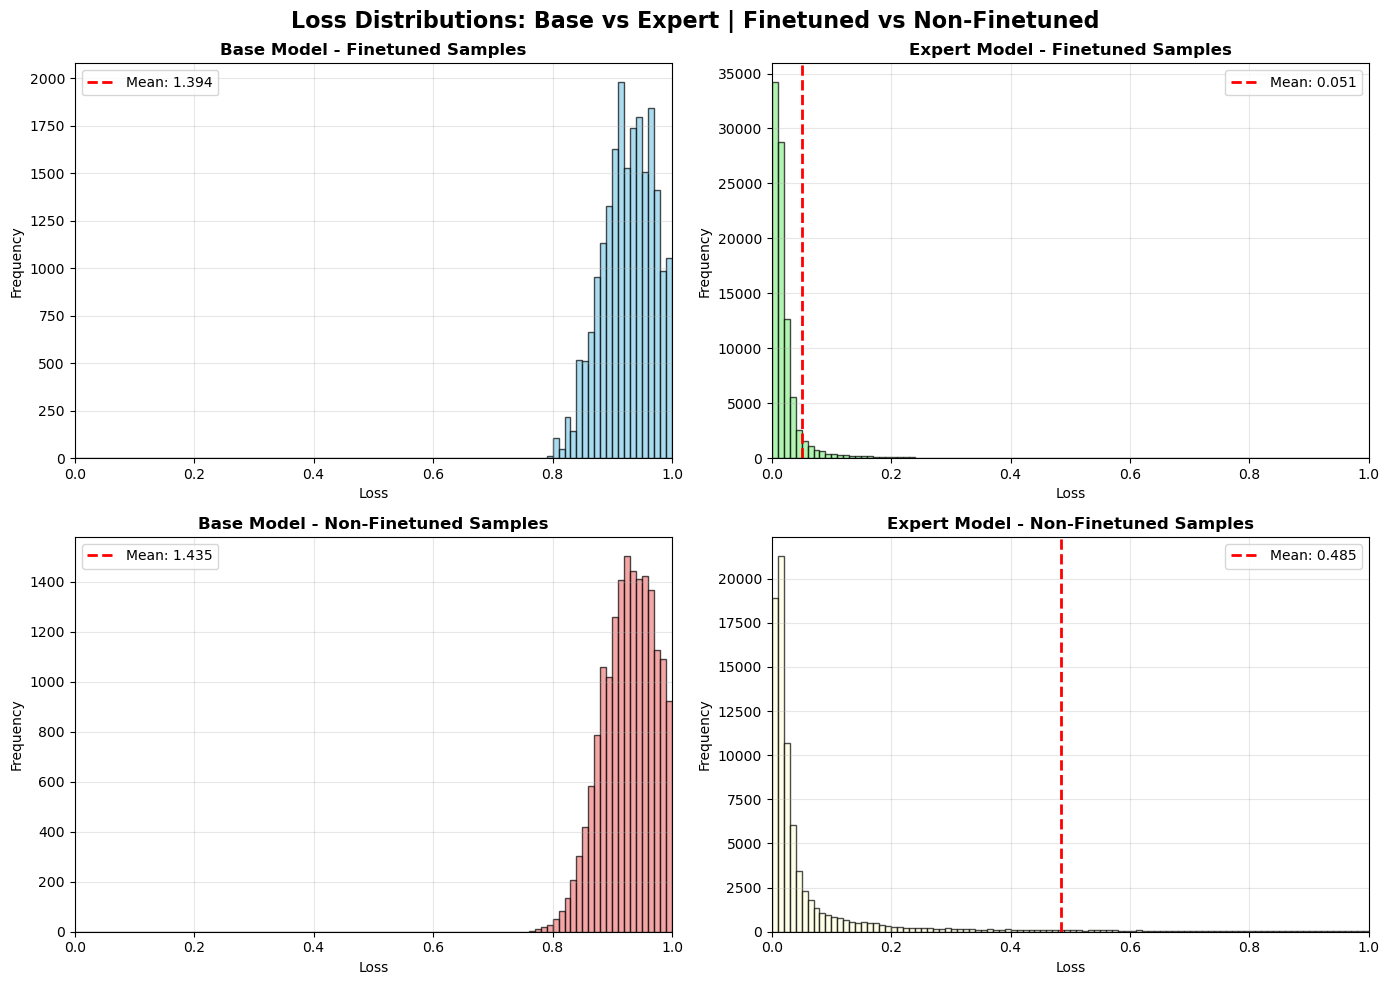


Percentage-reduction debug:
  FT  min/max: -423.54266 99.855995
  NFT min/max: -717.34344 99.84814
  FT  mean   : 96.515656
  NFT mean   : 65.79441


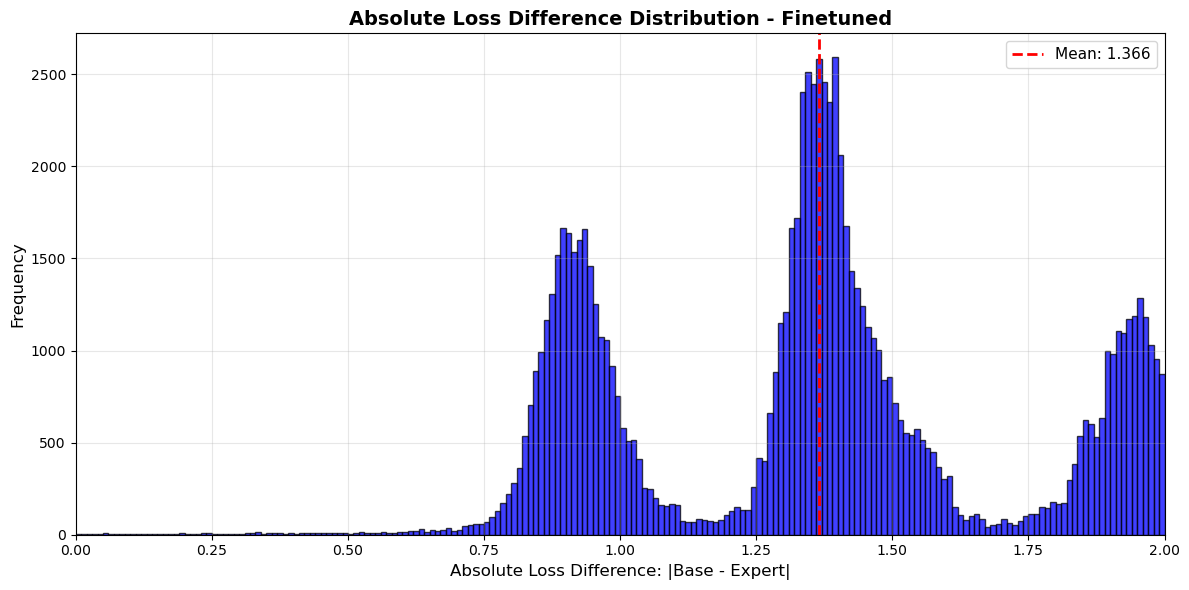

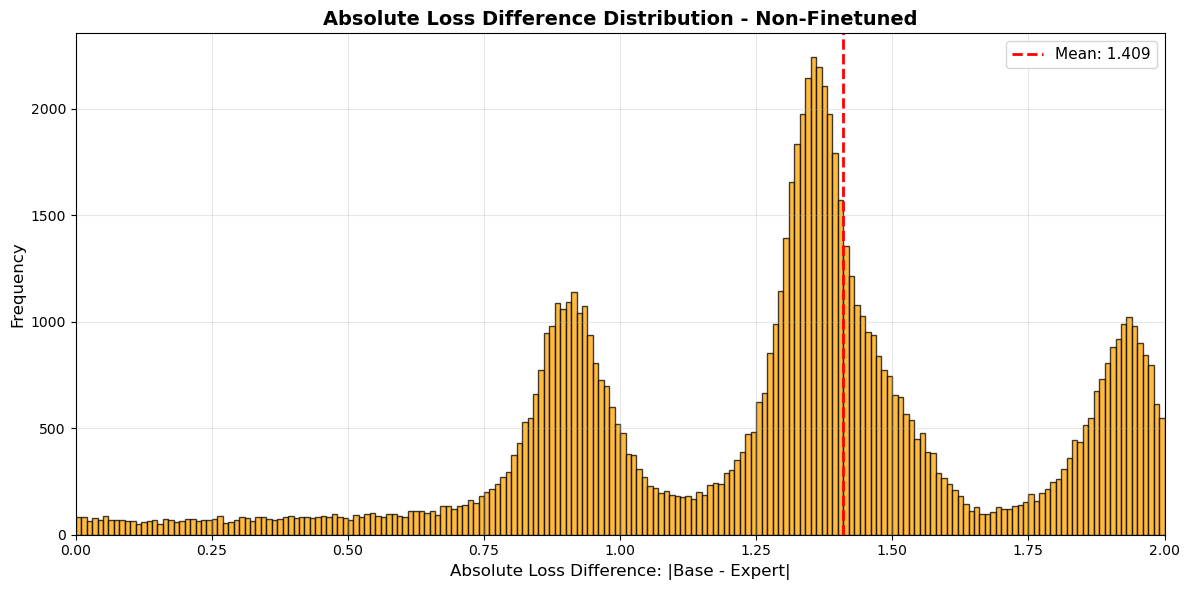

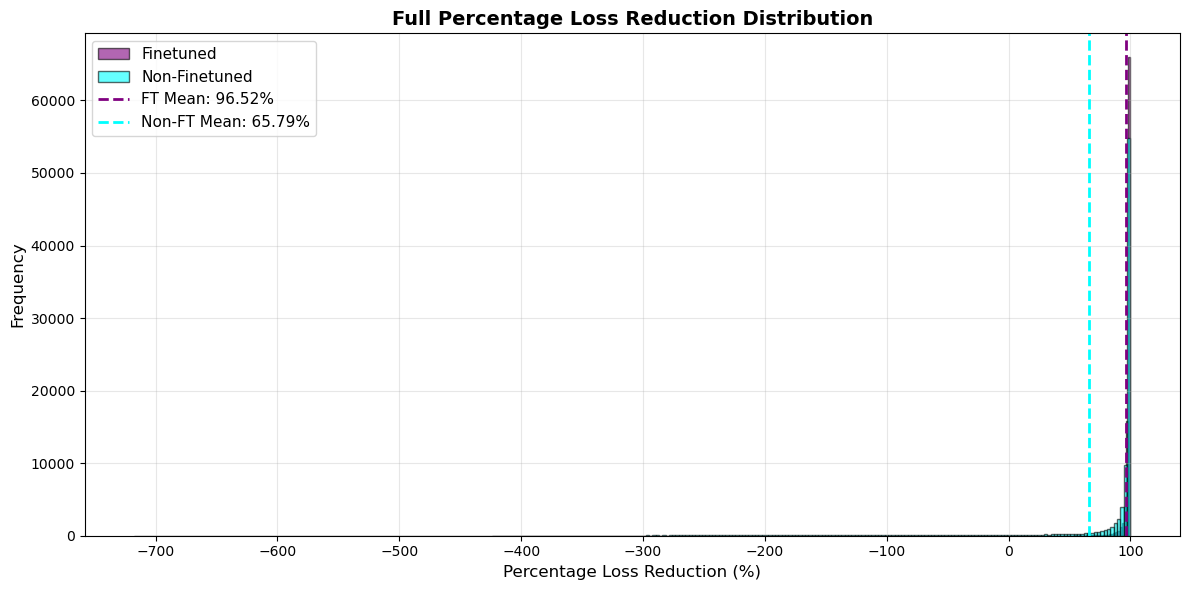

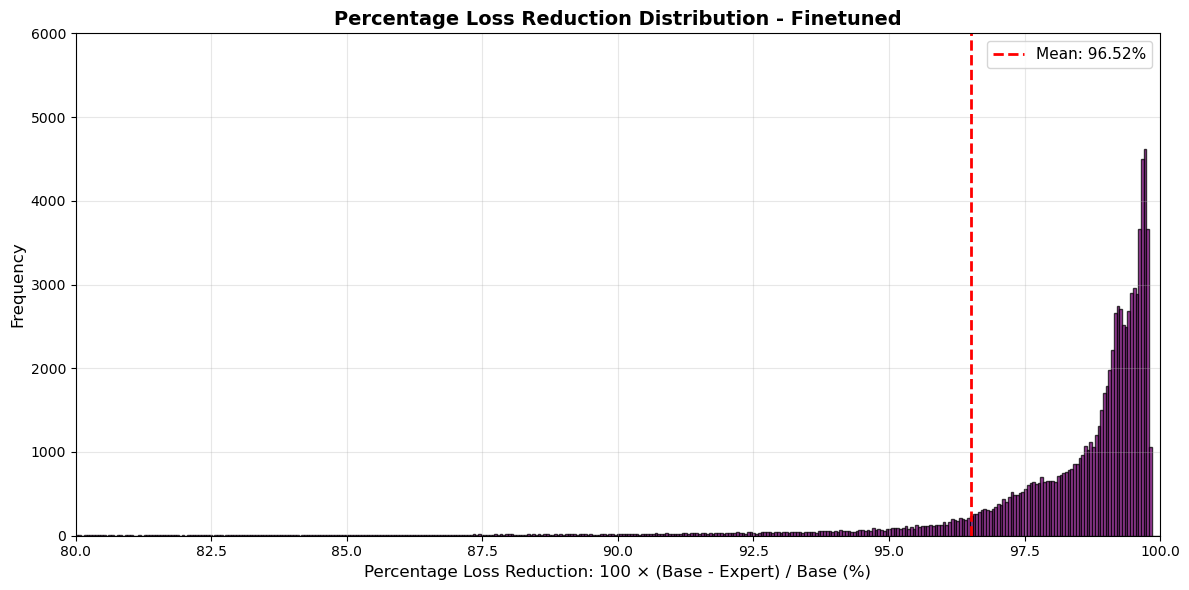

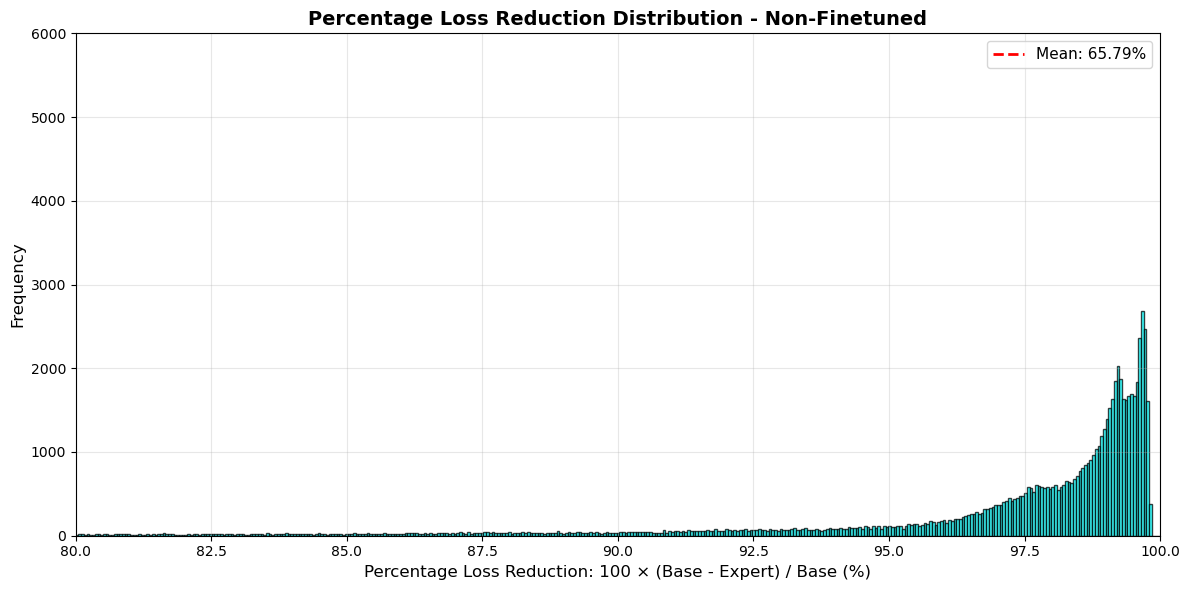

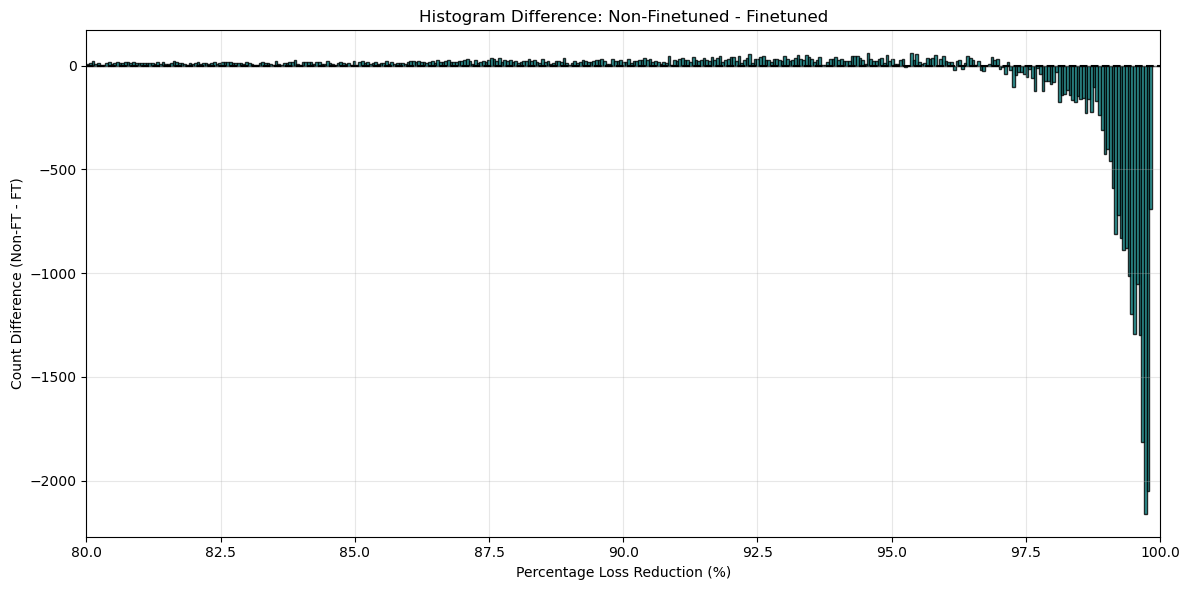


LOSS STATISTICS

Finetuned Samples:
  Base   - Mean: 1.3944, Std: 0.3597, Min: 0.7650, Max: 2.1483
  Expert - Mean: 0.0514, Std: 0.3036, Min: 0.0025, Max: 6.4150

Non-Finetuned Samples:
  Base   - Mean: 1.4350, Std: 0.3571, Min: 0.7650, Max: 2.1621
  Expert - Mean: 0.4852, Std: 1.2040, Min: 0.0026, Max: 7.3763

Absolute Loss Difference:
  Finetuned:     Mean: 1.3655, Std: 0.3741
  Non-Finetuned: Mean: 1.4093, Std: 0.6305

Percentage Loss Reduction:
  Finetuned:     Mean: 96.52%, Std: 17.51%
  Non-Finetuned: Mean: 65.79%, Std: 88.84%


In [94]:
def main():

    print(f"Loaded {len(all_losses_data)} experiments\n")

    # Aggregate
    all_base_ft, all_base_nft = [], []
    all_expert_ft, all_expert_nft = [], []

    for exp_data in all_losses_data:
        base = np.array(exp_data["base_losses"])
        expert = np.array(exp_data["expert_losses"])
        is_ft = np.array(exp_data["is_finetuned"], dtype=bool)

        all_base_ft.extend(base[is_ft])
        all_base_nft.extend(base[~is_ft])
        all_expert_ft.extend(expert[is_ft])
        all_expert_nft.extend(expert[~is_ft])

    all_base_ft = np.array(all_base_ft)
    all_base_nft = np.array(all_base_nft)
    all_expert_ft = np.array(all_expert_ft)
    all_expert_nft = np.array(all_expert_nft)

    print("Counts:")
    print("  FT :", len(all_base_ft))
    print("  NFT:", len(all_base_nft))

    # =========================================================================
    # VISUALIZATION 1: Loss Histograms
    # =========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        "Loss Distributions: Base vs Expert | Finetuned vs Non-Finetuned",
        fontsize=16,
        fontweight="bold"
    )

    bins_loss = np.linspace(0, 1, 101)

    axes[0, 0].hist(all_base_ft, bins=bins_loss, alpha=0.7, color="skyblue", edgecolor="black")
    axes[0, 0].axvline(np.mean(all_base_ft), color="red", linestyle="--", linewidth=2,
                       label=f"Mean: {np.mean(all_base_ft):.3f}")
    axes[0, 0].set_title("Base Model - Finetuned Samples", fontweight="bold")
    axes[0, 0].set_xlabel("Loss")
    axes[0, 0].set_ylabel("Frequency")
    axes[0, 0].set_xlim(0, 1)
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].hist(all_expert_ft, bins=bins_loss, alpha=0.7, color="lightgreen", edgecolor="black")
    axes[0, 1].axvline(np.mean(all_expert_ft), color="red", linestyle="--", linewidth=2,
                       label=f"Mean: {np.mean(all_expert_ft):.3f}")
    axes[0, 1].set_title("Expert Model - Finetuned Samples", fontweight="bold")
    axes[0, 1].set_xlabel("Loss")
    axes[0, 1].set_ylabel("Frequency")
    axes[0, 1].set_xlim(0, 1)
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].hist(all_base_nft, bins=bins_loss, alpha=0.7, color="lightcoral", edgecolor="black")
    axes[1, 0].axvline(np.mean(all_base_nft), color="red", linestyle="--", linewidth=2,
                       label=f"Mean: {np.mean(all_base_nft):.3f}")
    axes[1, 0].set_title("Base Model - Non-Finetuned Samples", fontweight="bold")
    axes[1, 0].set_xlabel("Loss")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].set_xlim(0, 1)
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].hist(all_expert_nft, bins=bins_loss, alpha=0.7, color="lightyellow", edgecolor="black")
    axes[1, 1].axvline(np.mean(all_expert_nft), color="red", linestyle="--", linewidth=2,
                       label=f"Mean: {np.mean(all_expert_nft):.3f}")
    axes[1, 1].set_title("Expert Model - Non-Finetuned Samples", fontweight="bold")
    axes[1, 1].set_xlabel("Loss")
    axes[1, 1].set_ylabel("Frequency")
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("viz1_loss_histograms.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # DERIVED QUANTITIES
    # =========================================================================
    # Absolute loss difference
    loss_diff_ft = np.abs(all_base_ft - all_expert_ft)
    loss_diff_nft = np.abs(all_base_nft - all_expert_nft)

    # Stable percentage reduction: ignore tiny base losses
    eps = 1e-4
    mask_ft = all_base_ft > eps
    mask_nft = all_base_nft > eps

    pct_reduction_ft = 100 * (all_base_ft[mask_ft] - all_expert_ft[mask_ft]) / all_base_ft[mask_ft]
    pct_reduction_nft = 100 * (all_base_nft[mask_nft] - all_expert_nft[mask_nft]) / all_base_nft[mask_nft]

    print("\nPercentage-reduction debug:")
    print("  FT  min/max:", np.min(pct_reduction_ft), np.max(pct_reduction_ft))
    print("  NFT min/max:", np.min(pct_reduction_nft), np.max(pct_reduction_nft))
    print("  FT  mean   :", np.mean(pct_reduction_ft))
    print("  NFT mean   :", np.mean(pct_reduction_nft))

    # =========================================================================
    # VISUALIZATION 2A: Absolute Loss Difference - Finetuned
    # =========================================================================
    bins_diff = np.linspace(0, 2, 201)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(loss_diff_ft, bins=bins_diff, alpha=0.75, color="blue", edgecolor="black")
    ax.axvline(np.mean(loss_diff_ft), color="red", linestyle="--", linewidth=2,
               label=f"Mean: {np.mean(loss_diff_ft):.3f}")
    ax.set_xlabel("Absolute Loss Difference: |Base - Expert|", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("Absolute Loss Difference Distribution - Finetuned", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 2)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("viz2a_loss_difference_finetuned.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # VISUALIZATION 2B: Absolute Loss Difference - Non-Finetuned
    # =========================================================================
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(loss_diff_nft, bins=bins_diff, alpha=0.75, color="orange", edgecolor="black")
    ax.axvline(np.mean(loss_diff_nft), color="red", linestyle="--", linewidth=2,
               label=f"Mean: {np.mean(loss_diff_nft):.3f}")
    ax.set_xlabel("Absolute Loss Difference: |Base - Expert|", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("Absolute Loss Difference Distribution - Non-Finetuned", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 2)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig( "viz2b_loss_difference_non_finetuned.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # VISUALIZATION 3FULL: Full Percentage Reduction Comparison
    # =========================================================================
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(pct_reduction_ft, bins=300, alpha=0.6, label="Finetuned", color="purple", edgecolor="black")
    ax.hist(pct_reduction_nft, bins=300, alpha=0.6, label="Non-Finetuned", color="cyan", edgecolor="black")
    ax.axvline(np.mean(pct_reduction_ft), color="purple", linestyle="--", linewidth=2,
               label=f"FT Mean: {np.mean(pct_reduction_ft):.2f}%")
    ax.axvline(np.mean(pct_reduction_nft), color="cyan", linestyle="--", linewidth=2,
               label=f"Non-FT Mean: {np.mean(pct_reduction_nft):.2f}%")
    ax.set_xlabel("Percentage Loss Reduction (%)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("Full Percentage Loss Reduction Distribution", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig( "viz3full_percentage_reduction_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # VISUALIZATION 3A: Percentage Loss Reduction - Finetuned
    # =========================================================================
    bins_pct = np.linspace(80, 100, 400)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(pct_reduction_ft, bins=bins_pct, alpha=0.75, color="purple", edgecolor="black")
    ax.axvline(np.mean(pct_reduction_ft), color="red", linestyle="--", linewidth=2,
               label=f"Mean: {np.mean(pct_reduction_ft):.2f}%")
    ax.axvline(0, color="black", linestyle=":", linewidth=1, alpha=0.5)
    ax.set_xlabel("Percentage Loss Reduction: 100 × (Base - Expert) / Base (%)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("Percentage Loss Reduction Distribution - Finetuned", fontsize=14, fontweight="bold")
    ax.set_xlim(80, 100)
    ax.set_ylim(0, 6000)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("viz3a_percentage_loss_reduction_finetuned.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # VISUALIZATION 3B: Percentage Loss Reduction - Non-Finetuned
    # =========================================================================
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(pct_reduction_nft, bins=bins_pct, alpha=0.75, color="cyan", edgecolor="black")
    ax.axvline(np.mean(pct_reduction_nft), color="red", linestyle="--", linewidth=2,
               label=f"Mean: {np.mean(pct_reduction_nft):.2f}%")
    ax.axvline(0, color="black", linestyle=":", linewidth=1, alpha=0.5)
    ax.set_xlabel("Percentage Loss Reduction: 100 × (Base - Expert) / Base (%)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("Percentage Loss Reduction Distribution - Non-Finetuned", fontsize=14, fontweight="bold")
    ax.set_xlim(80, 100)
    ax.set_ylim(0, 6000)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("viz3b_percentage_loss_reduction_non_finetuned.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # VISUALIZATION 4: Histogram Difference (Non-Finetuned - Finetuned)
    # =========================================================================
    counts_ft, edges = np.histogram(pct_reduction_ft, bins=bins_pct)
    counts_nft, _ = np.histogram(pct_reduction_nft, bins=bins_pct)
    counts_diff = counts_nft - counts_ft
    centers = (edges[:-1] + edges[1:]) / 2

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(centers, counts_diff, width=(edges[1] - edges[0]), color="teal", edgecolor="black", alpha=0.8)
    ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Percentage Loss Reduction (%)")
    ax.set_ylabel("Count Difference (Non-FT - FT)")
    ax.set_title("Histogram Difference: Non-Finetuned - Finetuned")
    ax.set_xlim(80, 100)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("viz4_hist_diff.png", dpi=300, bbox_inches="tight")
    plt.show()

    # =========================================================================
    # PRINT STATS
    # =========================================================================
    print("\n" + "=" * 70)
    print("LOSS STATISTICS")
    print("=" * 70)

    print("\nFinetuned Samples:")
    print(f"  Base   - Mean: {np.mean(all_base_ft):.4f}, Std: {np.std(all_base_ft):.4f}, Min: {np.min(all_base_ft):.4f}, Max: {np.max(all_base_ft):.4f}")
    print(f"  Expert - Mean: {np.mean(all_expert_ft):.4f}, Std: {np.std(all_expert_ft):.4f}, Min: {np.min(all_expert_ft):.4f}, Max: {np.max(all_expert_ft):.4f}")

    print("\nNon-Finetuned Samples:")
    print(f"  Base   - Mean: {np.mean(all_base_nft):.4f}, Std: {np.std(all_base_nft):.4f}, Min: {np.min(all_base_nft):.4f}, Max: {np.max(all_base_nft):.4f}")
    print(f"  Expert - Mean: {np.mean(all_expert_nft):.4f}, Std: {np.std(all_expert_nft):.4f}, Min: {np.min(all_expert_nft):.4f}, Max: {np.max(all_expert_nft):.4f}")

    print("\nAbsolute Loss Difference:")
    print(f"  Finetuned:     Mean: {np.mean(loss_diff_ft):.4f}, Std: {np.std(loss_diff_ft):.4f}")
    print(f"  Non-Finetuned: Mean: {np.mean(loss_diff_nft):.4f}, Std: {np.std(loss_diff_nft):.4f}")

    print("\nPercentage Loss Reduction:")
    print(f"  Finetuned:     Mean: {np.mean(pct_reduction_ft):.2f}%, Std: {np.std(pct_reduction_ft):.2f}%")
    print(f"  Non-Finetuned: Mean: {np.mean(pct_reduction_nft):.2f}%, Std: {np.std(pct_reduction_nft):.2f}%")

main()

In [9]:
## Compute the average MAE
## get the losses for the k points for each of the proportion
# for each proportion
# - apply that realtive threshold for all k points
# - get their label , 0 or 1 (1 means finetuned) for all k points
# - for all points marked as finetuned, compute the proportion (predicted proportion)
## compute the MAE between the true and predicted proportion
## get the average MAE 

In [112]:
def evaluate_experiment(threshold, eps=1e-4):
    maes = []

    for exp_data in all_losses_data:
        base_losses = np.array(exp_data['base_losses'])
        expert_losses = np.array(exp_data['expert_losses'])
        true_proportion = np.array(exp_data['true_proportion'])
        labels = np.array(exp_data['labels'])  # Now available!

        pct_reduction = np.full_like(base_losses, -np.inf, dtype=float)
        valid = base_losses > eps
        pct_reduction[valid] = 100 * (base_losses[valid] - expert_losses[valid]) / base_losses[valid]

        predicted_finetuned = pct_reduction > threshold

        selected_labels = labels[predicted_finetuned]

        if len(selected_labels) > 0:
            predicted_proportion = np.bincount(
                selected_labels,
                minlength=len(true_proportion)
            ).astype(float)
            predicted_proportion /= predicted_proportion.sum()
        else:
            predicted_proportion = np.zeros(len(true_proportion), dtype=float)

        mae = np.mean(np.abs(predicted_proportion - true_proportion))
        maes.append(mae)

    return np.mean(maes)


def main():
    # ============================================================
    # Sweep thresholds
    # ============================================================

    thresholds = np.linspace(30, 99.0, 50)   # fine-grained sweep
    mae_values = []

    print("Sweeping thresholds...")
    for t in thresholds:
        mae = evaluate_experiment(threshold=t)
        mae_values.append(mae)
        print(f"  Threshold: {t:.2f} → MAE: {mae:.6f}")

    # Convert to numpy
    thresholds = np.array(thresholds)
    mae_values = np.array(mae_values)

    # ============================================================
    # Find best threshold
    # ============================================================

    best_idx = np.argmin(mae_values)
    best_threshold = thresholds[best_idx]
    best_mae = mae_values[best_idx]

    print(f"\n{'='*70}")
    print(f"Best threshold: {best_threshold:.4f}")
    print(f"Best MAE: {best_mae:.6f}")
    print(f"{'='*70}")

    # ============================================================
    # Plot
    # ============================================================

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, mae_values, marker='o', linewidth=2, markersize=4, alpha=0.7)

    # Highlight best point
    plt.axvline(best_threshold, linestyle='--', color='red', linewidth=2, 
                label=f'Best: {best_threshold:.2f}% (MAE={best_mae:.4f})')
    plt.scatter(best_threshold, best_mae, color='red', s=100, zorder=5)

    plt.xlabel("Threshold (% Loss Reduction)", fontsize=12)
    plt.ylabel("Mean Absolute Error (MAE)", fontsize=12)
    plt.title("MAE vs Threshold - Finding Optimal Classification Point", fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("threshold_sweep.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ============================================================
    # Save results
    # ============================================================

    sweep_results = {
        'thresholds': thresholds,
        'mae_values': mae_values,
        'best_threshold': best_threshold,
        'best_mae': best_mae,
        'total_experiments': len(all_losses_data)
    }

    with open('threshold_sweep_results.pkl', 'wb') as f:
        pickle.dump(sweep_results, f)

    print("\n✓ Results saved to threshold_sweep_results.pkl")

Sweeping thresholds...
  Threshold: 30.00 → MAE: 0.056109
  Threshold: 31.41 → MAE: 0.055982
  Threshold: 32.82 → MAE: 0.055892
  Threshold: 34.22 → MAE: 0.055786
  Threshold: 35.63 → MAE: 0.055675
  Threshold: 37.04 → MAE: 0.055545
  Threshold: 38.45 → MAE: 0.055426
  Threshold: 39.86 → MAE: 0.055295
  Threshold: 41.27 → MAE: 0.055173
  Threshold: 42.67 → MAE: 0.055027
  Threshold: 44.08 → MAE: 0.054866
  Threshold: 45.49 → MAE: 0.054702
  Threshold: 46.90 → MAE: 0.054567
  Threshold: 48.31 → MAE: 0.054369
  Threshold: 49.71 → MAE: 0.054204
  Threshold: 51.12 → MAE: 0.054011
  Threshold: 52.53 → MAE: 0.053847
  Threshold: 53.94 → MAE: 0.053698
  Threshold: 55.35 → MAE: 0.053530
  Threshold: 56.76 → MAE: 0.053385
  Threshold: 58.16 → MAE: 0.053234
  Threshold: 59.57 → MAE: 0.053078
  Threshold: 60.98 → MAE: 0.052868
  Threshold: 62.39 → MAE: 0.052677
  Threshold: 63.80 → MAE: 0.052431
  Threshold: 65.20 → MAE: 0.052230
  Threshold: 66.61 → MAE: 0.051979
  Threshold: 68.02 → MAE: 0.0517

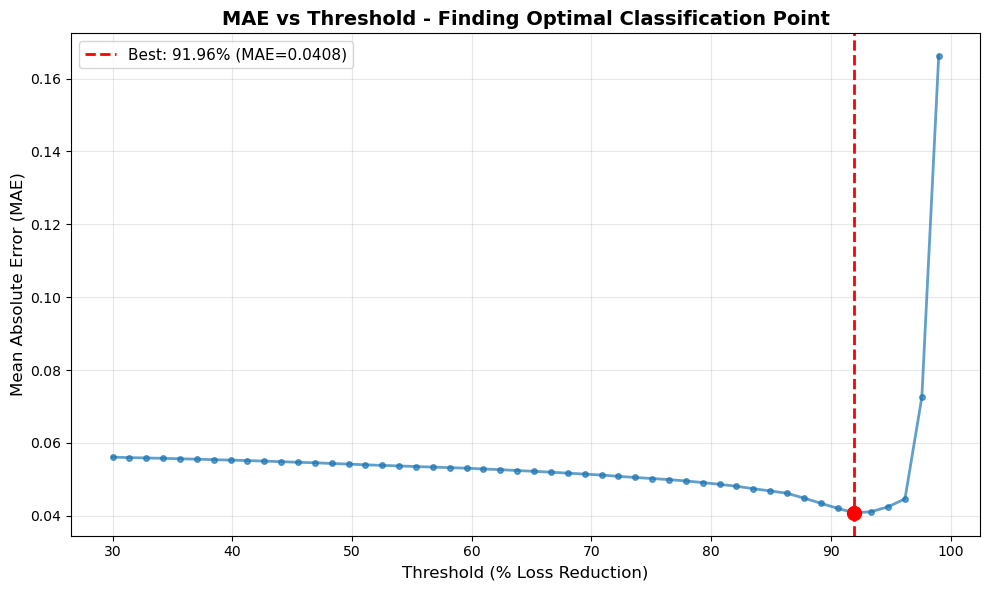


✓ Results saved to threshold_sweep_results.pkl


In [113]:
main()